# Part 1: Data Analysis & Visualization

In [4]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120

os.makedirs("../assets/plots", exist_ok=True)

Define an helper function to load and concatenate the `.csv` logs into a single Pandas DataFrame, adding metadata for algorithms and seeds.

In [5]:
def load_exp_data(log_dir="../logs/part1"):
    experiment_map = {
        "reinforce_vanilla.csv": ("REINFORCE (Vanilla)", 42),
        "reinforce_base20.csv": ("REINFORCE (Base 20)", 42),
        "reinforce_norm_42.csv": ("REINFORCE (Norm)", 42),
        "reinforce_norm_43.csv": ("REINFORCE (Norm)", 43),
        "reinforce_norm_44.csv": ("REINFORCE (Norm)", 44),
        "ac_s42.csv": ("Actor-Critic", 42),
        "ac_s43.csv": ("Actor-Critic", 43),
        "ac_s44.csv": ("Actor-Critic", 44),
    }

    df_list = []
    for filename, (algo, seed) in experiment_map.items():
        filepath = os.path.join(log_dir, filename)
        if os.path.exists(filepath):
            df = pd.read_csv(filepath)
            df["Algorithm"] = algo
            df["Seed"] = seed
            df_list.append(df)
        else:
            print(f"Warning: {filename} not found.")

    return pd.concat(df_list, ignore_index=True)

In [6]:
df = load_exp_data()
df.head()

,episode,reward,actor_loss,critic_loss,mean_value,mean_sigma,Algorithm,Seed
0,1,10.146968,289.725250,0.0,0.0,0.974700,REINFORCE (Vanilla),42
1,2,18.064679,701.153320,0.0,0.0,0.975100,REINFORCE (Vanilla),42
2,3,38.106414,2416.079834,0.0,0.0,0.975419,REINFORCE (Vanilla),42
3,4,7.589325,134.659790,0.0,0.0,0.975601,REINFORCE (Vanilla),42
4,5,26.505868,1680.192993,0.0,0.0,0.975687,REINFORCE (Vanilla),42


## REINFORCE Ablation Study

Visualize the impact of the baseline and return normalization on the Episode Reward and the Actor Loss.

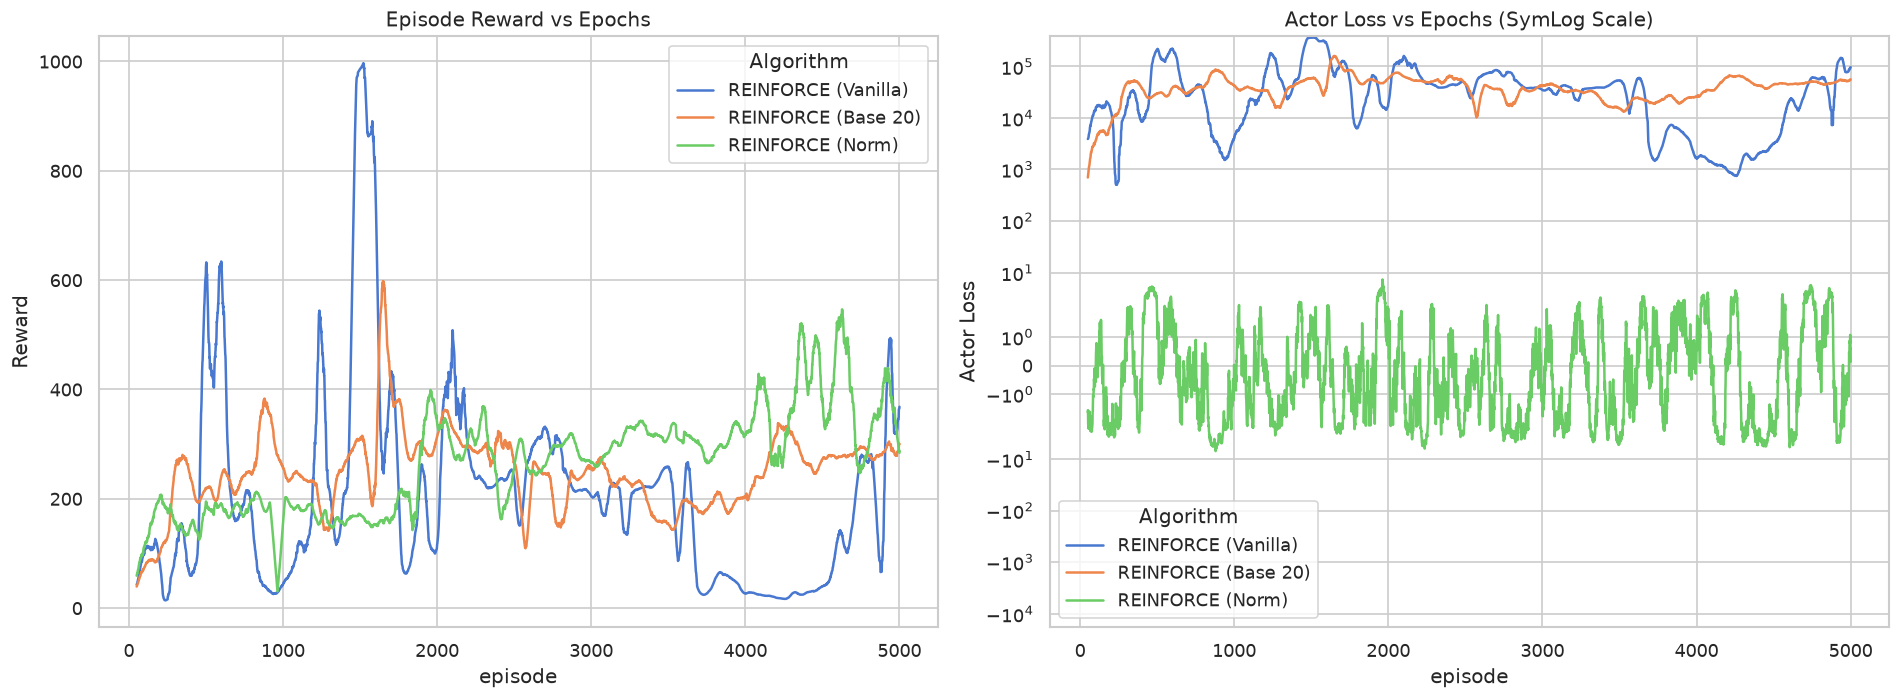

In [7]:
df_ablation = df[(df["Seed"] == 42) & (df["Algorithm"].str.contains("REINFORCE"))]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

window_size = 50

df_ablation["reward_smooth"] = df_ablation.groupby("Algorithm")["reward"].transform(
    lambda s: s.rolling(window_size).mean()
)
df_ablation["loss_smooth"] = df_ablation.groupby("Algorithm")["actor_loss"].transform(
    lambda s: s.rolling(window_size).mean()
)

sns.lineplot(
    data=df_ablation, x="episode", y="reward_smooth", hue="Algorithm", ax=axes[0]
)
axes[0].set_title("Episode Reward vs Epochs")
axes[0].set_ylabel("Reward")

sns.lineplot(
    data=df_ablation, x="episode", y="loss_smooth", hue="Algorithm", ax=axes[1]
)
axes[1].set_title("Actor Loss vs Epochs (SymLog Scale)")
axes[1].set_ylabel("Actor Loss")
axes[1].set_yscale("symlog")

plt.tight_layout()
plt.savefig("../assets/plots/reinforce_ablation.png")
plt.show()

## REINFORCE vs. Actor-Critic

Comparing the *mathematically stabilized* REINFORCE model (Normalized) against Actor-Critic across 3 different random seeds.

> Why normalized and not vanilla? Although Vanilla REINFORCE occasionally reached higher peak rewards ($\approx 900$), those peaks were statistical flukes caused by unbounded gradient variance and are highly not-reproducible. The Normalized version represents the true, stable optimization capacity of the algorithm.

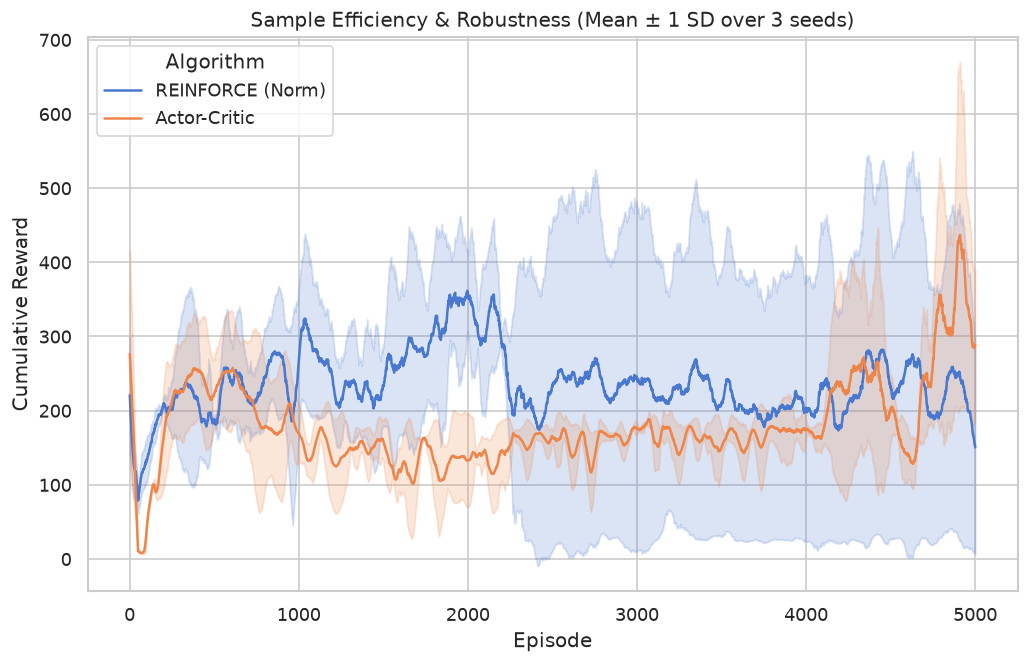

In [8]:
df_comparison = df[df["Algorithm"].isin(["REINFORCE (Norm)", "Actor-Critic"])]

plt.figure(figsize=(10, 6))

df_comparison["reward_smooth"] = df_comparison.groupby("Algorithm")["reward"].transform(
    lambda s: s.rolling(window_size).mean()
)

sns.lineplot(
    data=df_comparison, x="episode", y="reward_smooth", hue="Algorithm", errorbar="sd"
)

plt.title("Sample Efficiency & Robustness (Mean ± 1 SD over 3 seeds)")
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")

plt.savefig("../assets/plots/ac_vs_reinforce.png")
plt.show()

## Deep Analytics: Exploration Dinamics ($\sigma$ Anomaly)

In standard continuous control, exploration noise ($\sigma$) is expected to monotonically decay as the policy converges.

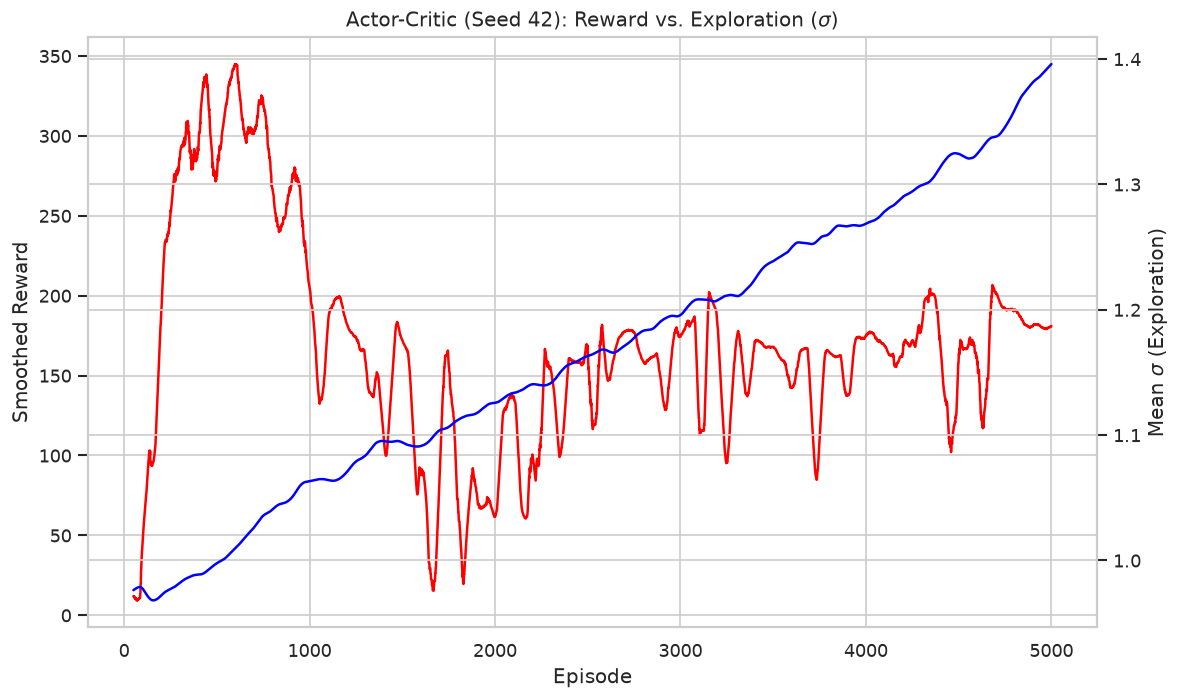

In [9]:
df_ac_42 = df[(df["Algorithm"] == "Actor-Critic") & (df["Seed"] == 42)]

df_ac_42["reward_smooth"] = df_ac_42["reward"].rolling(window=window_size).mean()
df_ac_42["sigma_smooth"] = df_ac_42["mean_sigma"].rolling(window=window_size).mean()

fig, ax = plt.subplots(figsize=(10, 6))
ax2 = ax.twinx()

sns.lineplot(data=df_ac_42, x="episode", y="reward_smooth", ax=ax, color="red")
sns.lineplot(data=df_ac_42, x="episode", y="sigma_smooth", ax=ax2, color="blue")

plt.title("Actor-Critic (Seed 42): Reward vs. Exploration ($\\sigma$)")
ax.set_xlabel("Episode")
ax.set_ylabel("Smoothed Reward")
ax2.set_ylabel("Mean $\\sigma$ (Exploration)")

plt.tight_layout()
plt.savefig("../assets/plots/ac_sigma_analysis.png")
plt.show()

## Critic Convergence (Value Function Evaluation)

The stability of the Actor relies entirely on the accuracy of the Critic's Advantage estimations.

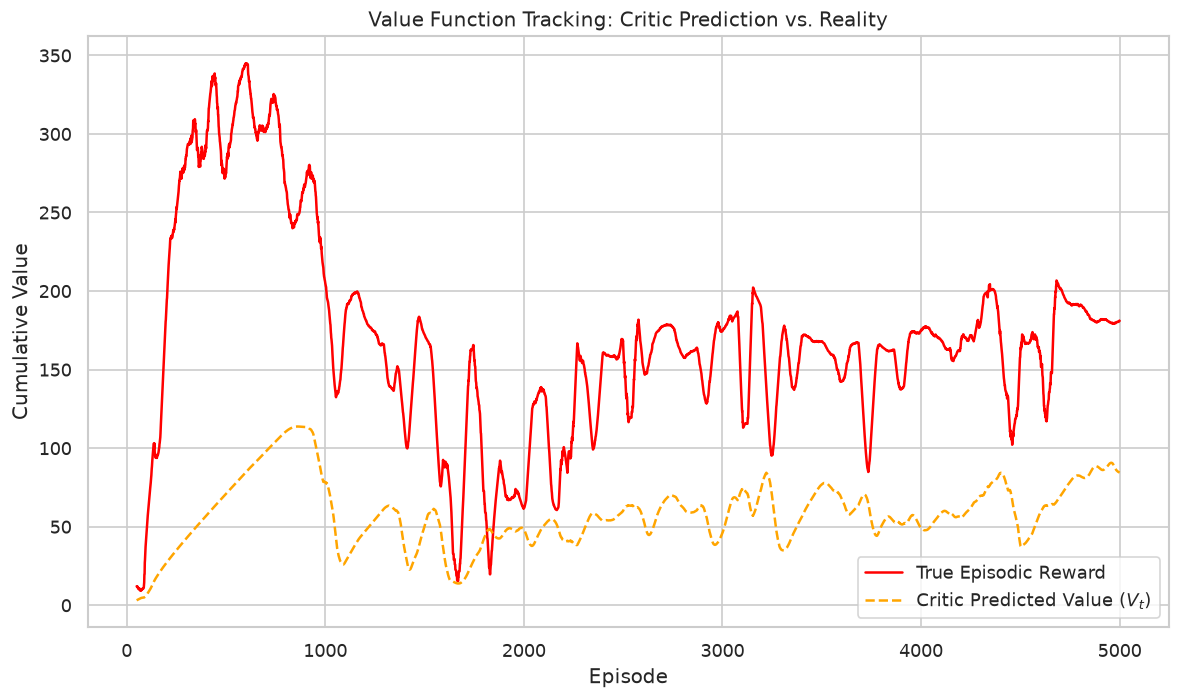

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

df_ac_42["value_smooth"] = df_ac_42["mean_value"].rolling(window=window_size).mean()

sns.lineplot(
    data=df_ac_42,
    x="episode",
    y="reward_smooth",
    label="True Episodic Reward",
    color="red",
)
sns.lineplot(
    data=df_ac_42,
    x="episode",
    y="value_smooth",
    label="Critic Predicted Value ($V_t$)",
    color="orange",
    linestyle="--",
)

plt.title("Value Function Tracking: Critic Prediction vs. Reality")
plt.xlabel("Episode")
plt.ylabel("Cumulative Value")
plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig("../assets/plots/critic_tracking.png")
plt.show()